In [1]:
import pandas as pd
from pathlib import Path

In [2]:
DATA_PATH = Path("../data/churn.csv")

df = pd.read_csv(DATA_PATH)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df['TotalCharges']=pd.to_numeric(df["TotalCharges"], errors="coerce")

In [8]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [9]:
df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [10]:
df= df.dropna(subset=["TotalCharges"]).copy()

In [11]:
df["TotalCharges"].isnull().sum()


np.int64(0)

In [12]:
df.shape

(7032, 21)

In [13]:
df["Churn"]=df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [14]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [16]:
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Contract",
    "InternetService"
]

X = df[features]
y = df["Churn"]

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [19]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((5625, 5), (1407, 5), (5625,), (1407,))

In [20]:
y_train.value_counts(normalize=True)

Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

In [21]:
y_test.value_counts(normalize=True)

Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64

In [22]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = ["Contract", "InternetService"]

In [23]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [24]:
numeric_transformer = Pipeline(steps=[
     ("imputer", SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

In [25]:
categorical_transformer=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

In [26]:
from sklearn.compose import ColumnTransformer


In [27]:
preprocessor=ColumnTransformer(
    transformers=[
        ("num",numeric_transformer, numeric_features),
        ("cat",categorical_transformer, categorical_features)
    ]
)

In [28]:
from sklearn.linear_model import LogisticRegression


In [29]:
model= Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [30]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['tenure','MonthlyCharges','TotalCharges','Contract','InternetService']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [31]:
train_accuracy = model.score(X_train, y_train)
train_accuracy

0.7902222222222223

In [32]:
test_accuracy=model.score(X_test, y_test)
test_accuracy

0.7839374555792467

In [33]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



## The first Logistic Regression model achieved around 78% test accuracy. 
    However, the recall for churned customers was only 48%, meaning the model missed many actual churn cases. 
    Since the business goal is to identify customers likely to leave, improving recall for class 1 is more important than accuracy alone.

In [34]:
confusion_matrix(y_test, y_pred)

array([[922, 111],
       [193, 181]])

The confusion matrix shows that the model correctly predicted 922 non-churn customers and 181 churn customers. However, it missed 193 customers who actually churned by predicting them as non-churn. This is important because false negatives are costly in churn prediction: the company may fail to identify customers who are likely to leave. Therefore, the next improvement should focus on increasing recall for class 1.

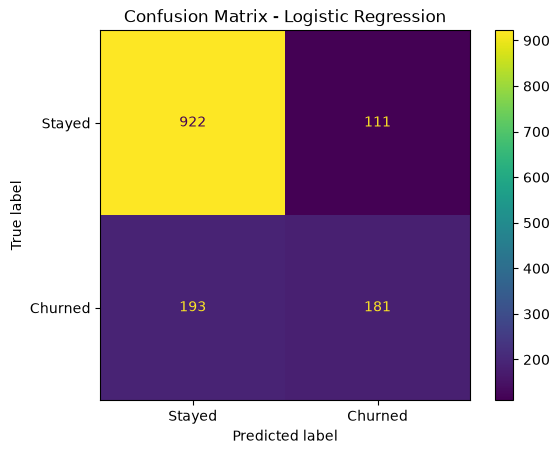

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Stayed", "Churned"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [36]:
model_balanced = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1033
           1       0.48      0.81      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.73      1407



After using class_weight="balanced", the model's recall for churn customers improved from 48% to 81%. This means the model is now much better at identifying customers who are likely to churn. Although overall accuracy decreased from 78% to 72% and precision for churn decreased, this trade-off is acceptable for a churn prediction system because missing actual churn customers is more costly than flagging some extra customers as risky.

In [37]:
confusion_matrix(y_test, y_pred_balanced)

array([[705, 328],
       [ 72, 302]])

The balanced Logistic Regression model significantly improved churn detection. The number of missed churn customers decreased from 193 to 72, while correctly detected churn customers increased from 181 to 302. Although the number of false positives increased, this trade-off is acceptable because the goal of a churn prediction system is to identify as many at-risk customers as possible before they leave.

In [39]:
features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges"
]

X = df[features]
y = df["Churn"]

In [40]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [43]:
model_balanced_full = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model_balanced_full.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [44]:
y_pred_balanced_full = model_balanced_full.predict(X_test)

print(classification_report(y_test, y_pred_balanced_full))

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [45]:
confusion_matrix(y_test, y_pred_balanced_full)

array([[723, 310],
       [ 76, 298]])

In [47]:
y_proba = model_balanced_full.predict_proba(X_test)[:, 1]

threshold = 0.40

y_pred_threshold = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_threshold))

confusion_matrix(y_test, y_pred_threshold)

              precision    recall  f1-score   support

           0       0.93      0.62      0.74      1033
           1       0.45      0.87      0.60       374

    accuracy                           0.69      1407
   macro avg       0.69      0.74      0.67      1407
weighted avg       0.80      0.69      0.70      1407



array([[638, 395],
       [ 48, 326]])

In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    cm = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()

    print("Threshold:", threshold)
    print("Precision:", round(precision, 3))
    print("Recall:", round(recall, 3))
    print("F1-score:", round(f1, 3))
    print("False Negatives:", fn)
    print("False Positives:", fp)
    print("Confusion Matrix:")
    print(cm)
    print("-" * 40)

Threshold: 0.5
Precision: 0.49
Recall: 0.797
F1-score: 0.607
False Negatives: 76
False Positives: 310
Confusion Matrix:
[[723 310]
 [ 76 298]]
----------------------------------------
Threshold: 0.45
Precision: 0.47
Recall: 0.832
F1-score: 0.6
False Negatives: 63
False Positives: 351
Confusion Matrix:
[[682 351]
 [ 63 311]]
----------------------------------------
Threshold: 0.4
Precision: 0.452
Recall: 0.872
F1-score: 0.595
False Negatives: 48
False Positives: 395
Confusion Matrix:
[[638 395]
 [ 48 326]]
----------------------------------------
Threshold: 0.35
Precision: 0.428
Recall: 0.901
F1-score: 0.581
False Negatives: 37
False Positives: 450
Confusion Matrix:
[[583 450]
 [ 37 337]]
----------------------------------------
Threshold: 0.3
Precision: 0.415
Recall: 0.93
F1-score: 0.574
False Negatives: 26
False Positives: 491
Confusion Matrix:
[[542 491]
 [ 26 348]]
----------------------------------------


After comparing multiple probability thresholds, 0.45 was selected as the final decision threshold. At this threshold, churn recall improved to 83.2%, and false negatives decreased from 76 to 63 compared to the default 0.50 threshold. The F1-score remained close to the best value, making 0.45 a good balance between catching churn customers and avoiding too many false positives.

In [50]:
final_threshold = 0.45

y_proba = model_balanced_full.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba >= final_threshold).astype(int)

print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.92      0.66      0.77      1033
           1       0.47      0.83      0.60       374

    accuracy                           0.71      1407
   macro avg       0.69      0.75      0.68      1407
weighted avg       0.80      0.71      0.72      1407

[[682 351]
 [ 63 311]]


In [51]:
import joblib

joblib.dump(model_balanced_full, "../saved_model/churn_model.pkl")

['../saved_model/churn_model.pkl']

In [52]:
import os

os.path.exists("../saved_model/churn_model.pkl")

True